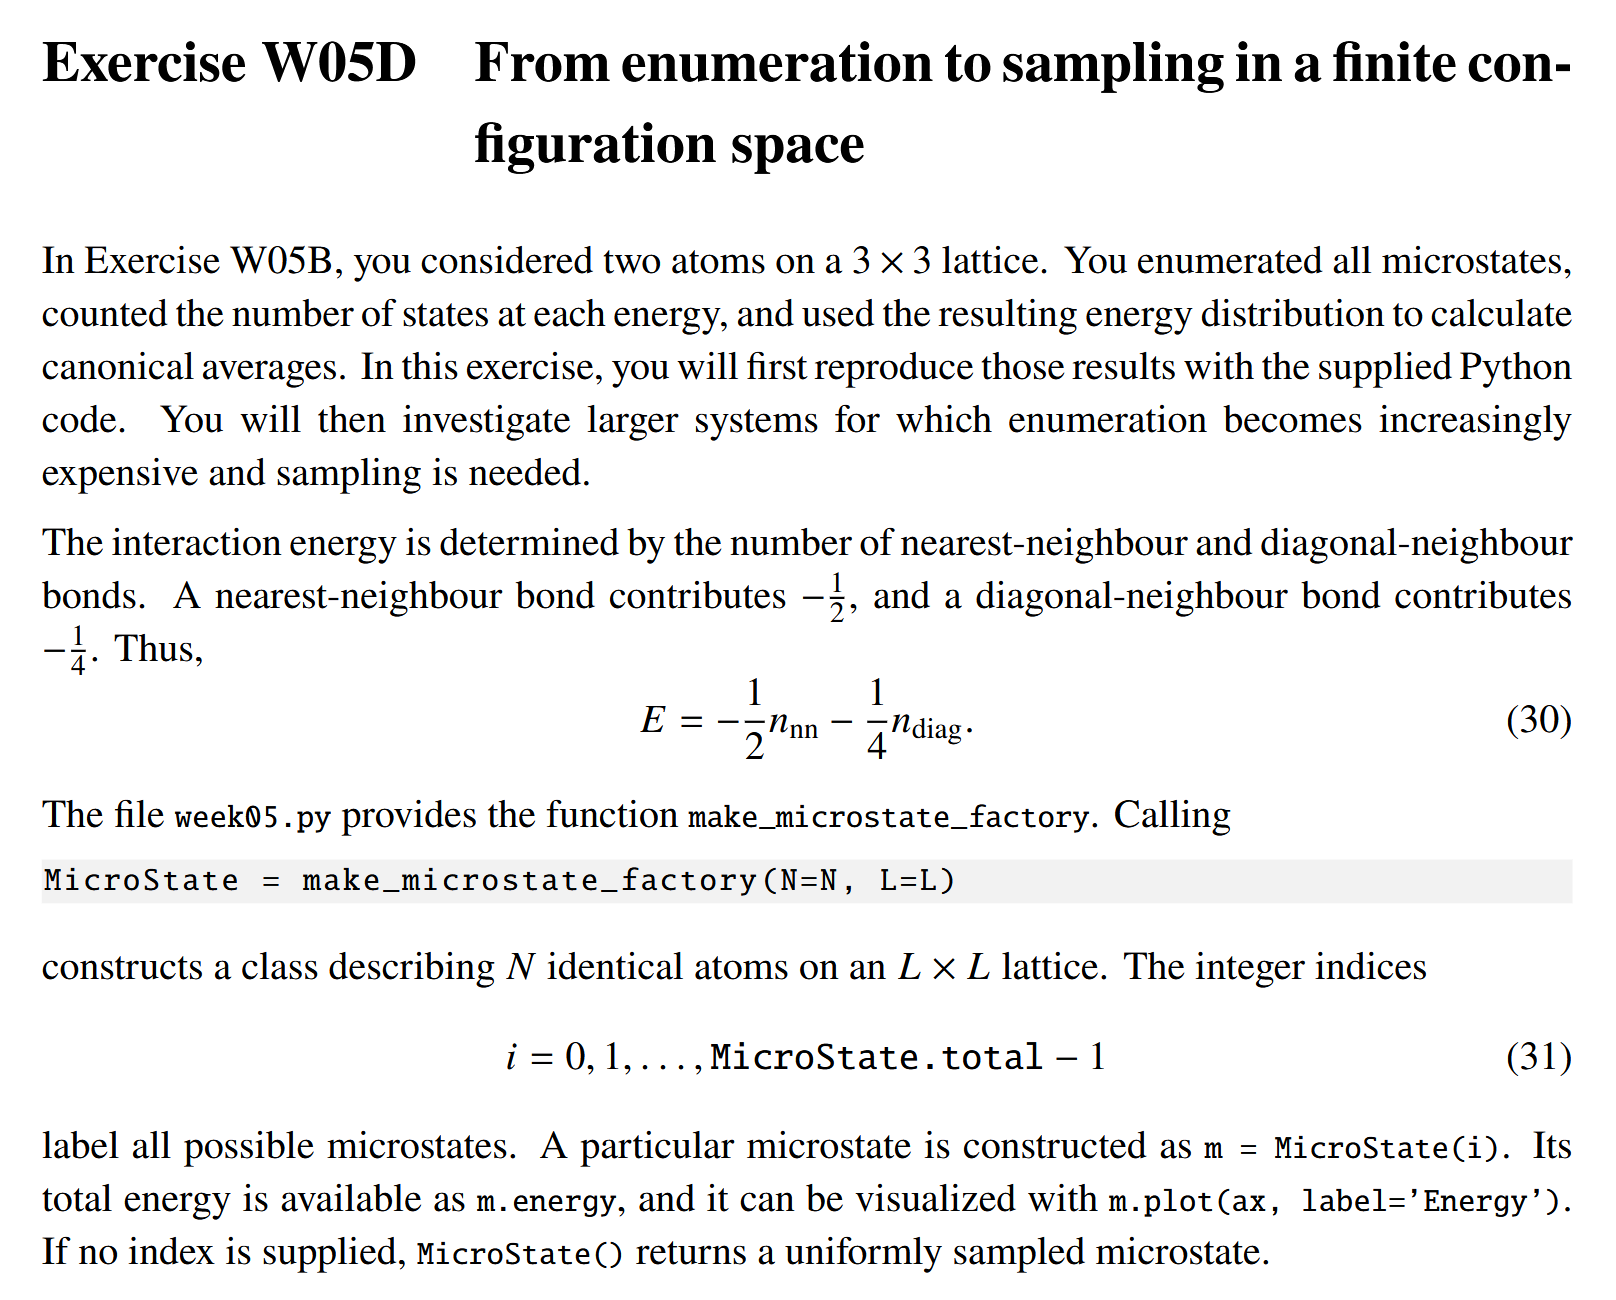
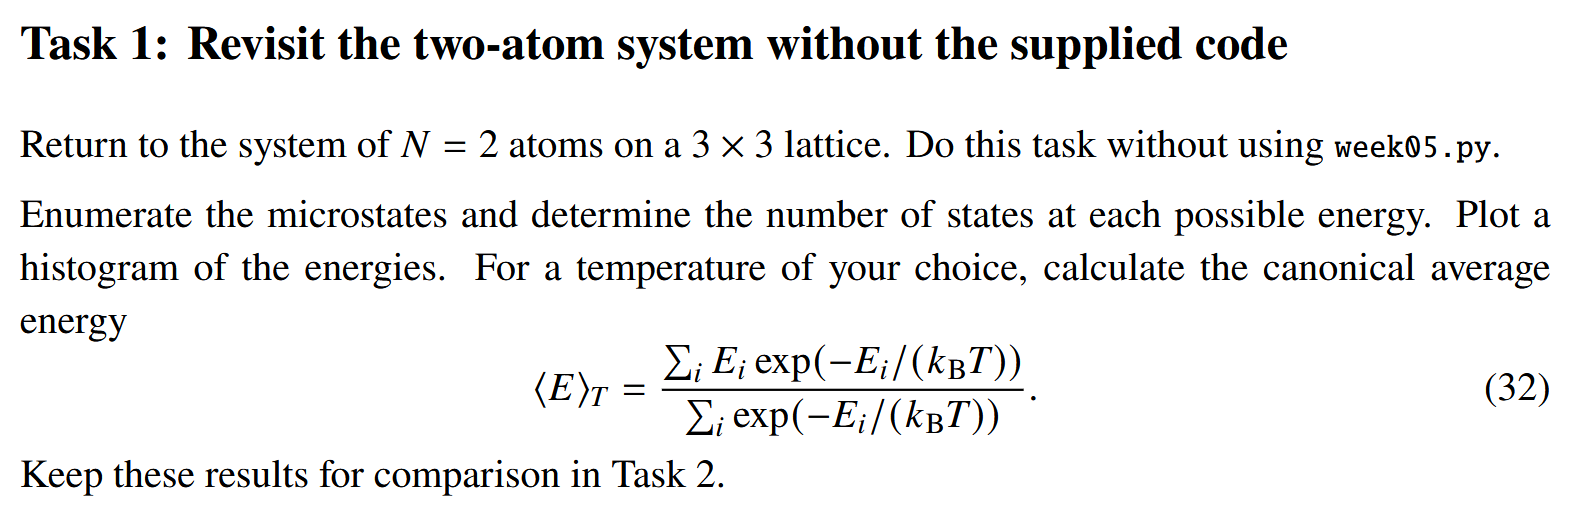

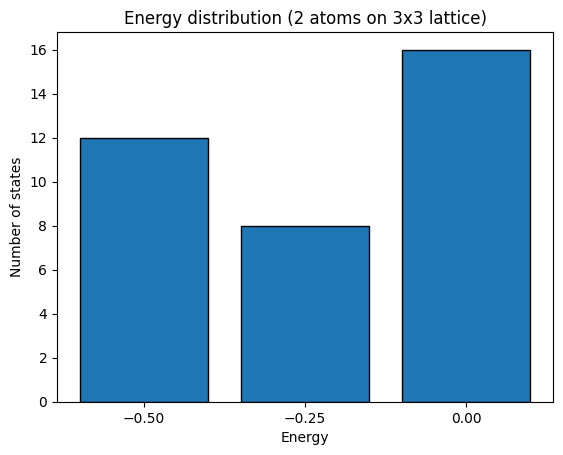

Canonical average energy at kbT=1.0: -0.271


In [2]:
import numpy as np
import matplotlib.pyplot as plt 

energy_levels = np.array([-0.5, -0.25, 0.0])
num_states = np.array([12, 8, 16])

plt.bar(energy_levels, num_states, width=0.2, edgecolor='black')
plt.xticks([-0.5, -0.25, 0.0])
plt.xlabel('Energy')
plt.ylabel('Number of states')
plt.title('Energy distribution (2 atoms on 3x3 lattice)')
plt.show()

kbT = 1.0

def canonical_energy(energy_levels, num_states, kbT):
    boltzmann_factors = np.exp(-energy_levels / (kbT))

    numerator = np.sum(energy_levels * num_states * boltzmann_factors)
    denominator = np.sum(num_states * boltzmann_factors)

    return (numerator / denominator)

print(f"Canonical average energy at kbT={kbT}: {canonical_energy(energy_levels, num_states, kbT):.3f}")

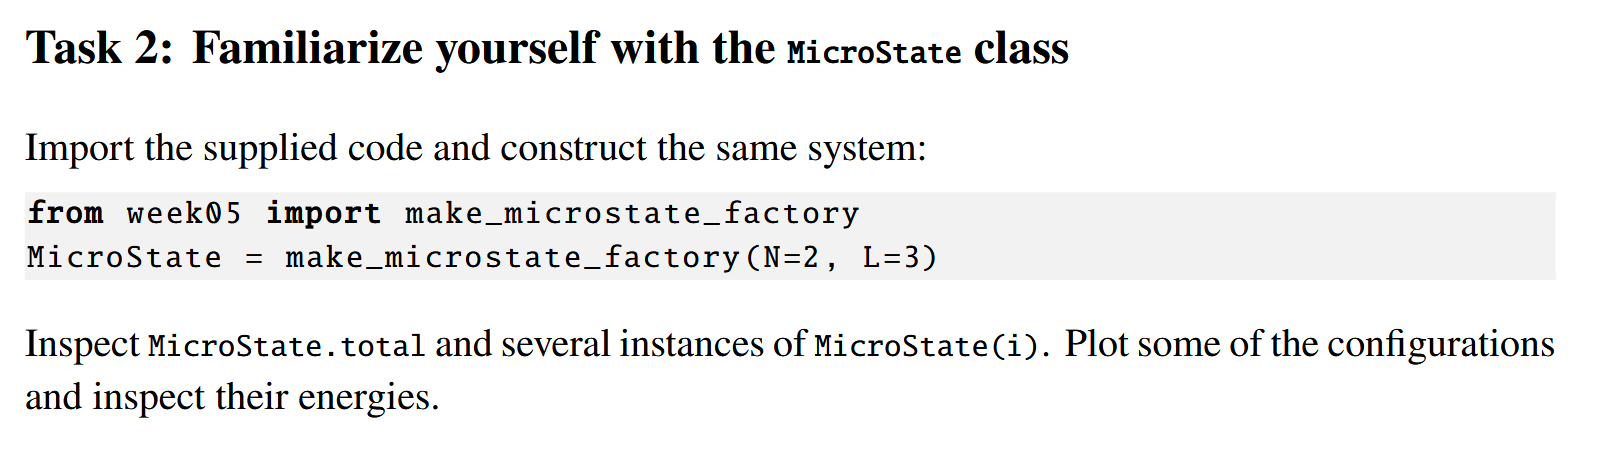
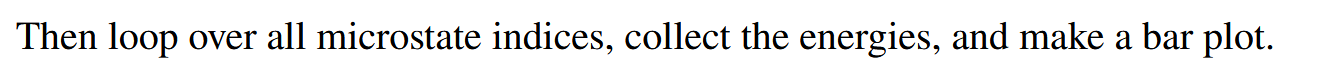
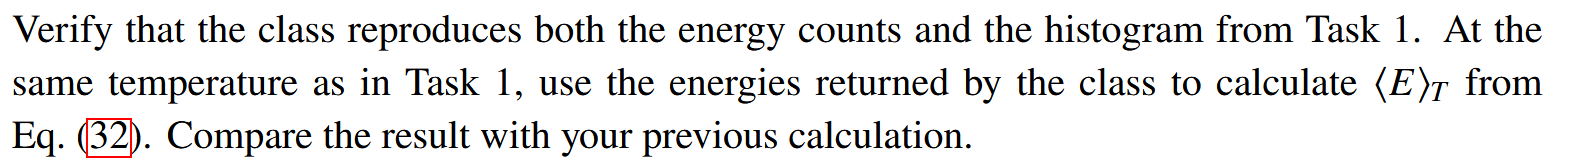

36
MicroState #0 of 36 with E=-0.5 for N=2 in LxL=3x3
MicroState #1 of 36 with E=-0.0 for N=2 in LxL=3x3
MicroState #2 of 36 with E=-0.5 for N=2 in LxL=3x3
Canonical average energy at kbT=1.0: -0.271


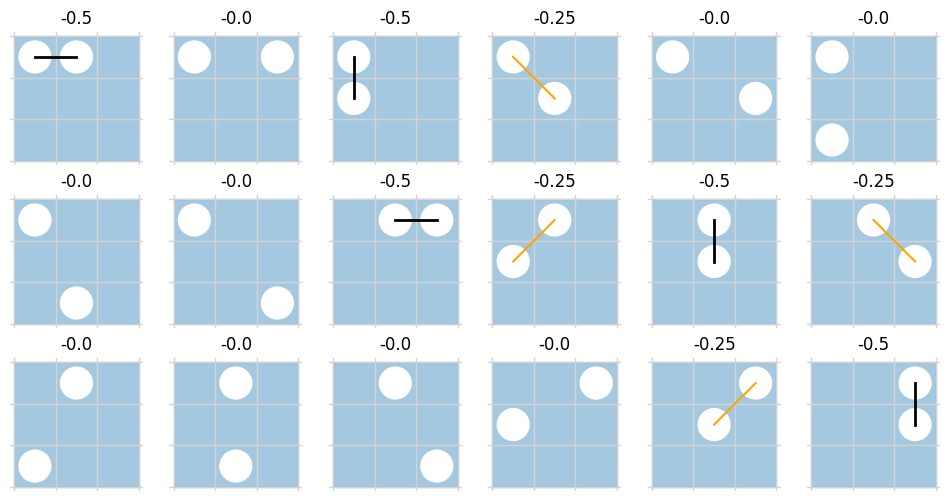

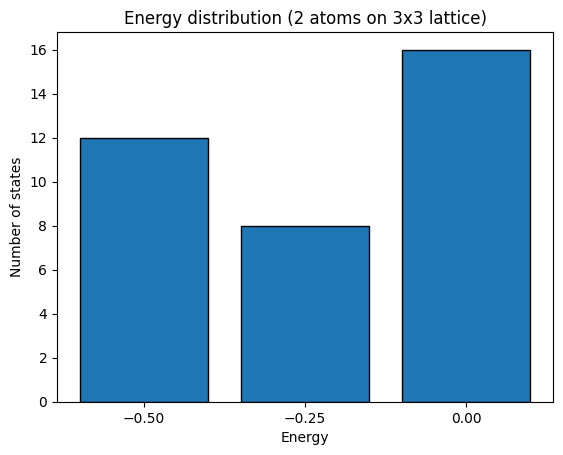

In [3]:
from week05 import * 
MicroState = make_microstate_factory(N=2, L=3)

print(MicroState.total)
for i in range(3):
    print(MicroState(i))

fig, axes = plt.subplots(3,6, figsize=(12,6))
axes = axes.flatten()

energies = []
for i, ax in enumerate(axes):
    state = MicroState(i)
    state.plot(ax)
    energies.append(state.energy)
    ax.set_title(f'{state.energy}')

for i in range(MicroState.total-len(axes), MicroState.total):
    energies.append(MicroState(i).energy)

fig2, ax2 = plt.subplots(1, 1)

unique_energies, state_counts = np.unique(energies, return_counts=True)
ax2.bar(unique_energies, state_counts, width=0.2, align='center', edgecolor='black')

ax2.set_xticks(unique_energies)
ax2.set_xlabel('Energy')
ax2.set_ylabel('Number of states')
ax2.set_title('Energy distribution (2 atoms on 3x3 lattice)')


print(f"Canonical average energy at kbT={kbT}: {canonical_energy(unique_energies, state_counts, 1.0):.3f}")

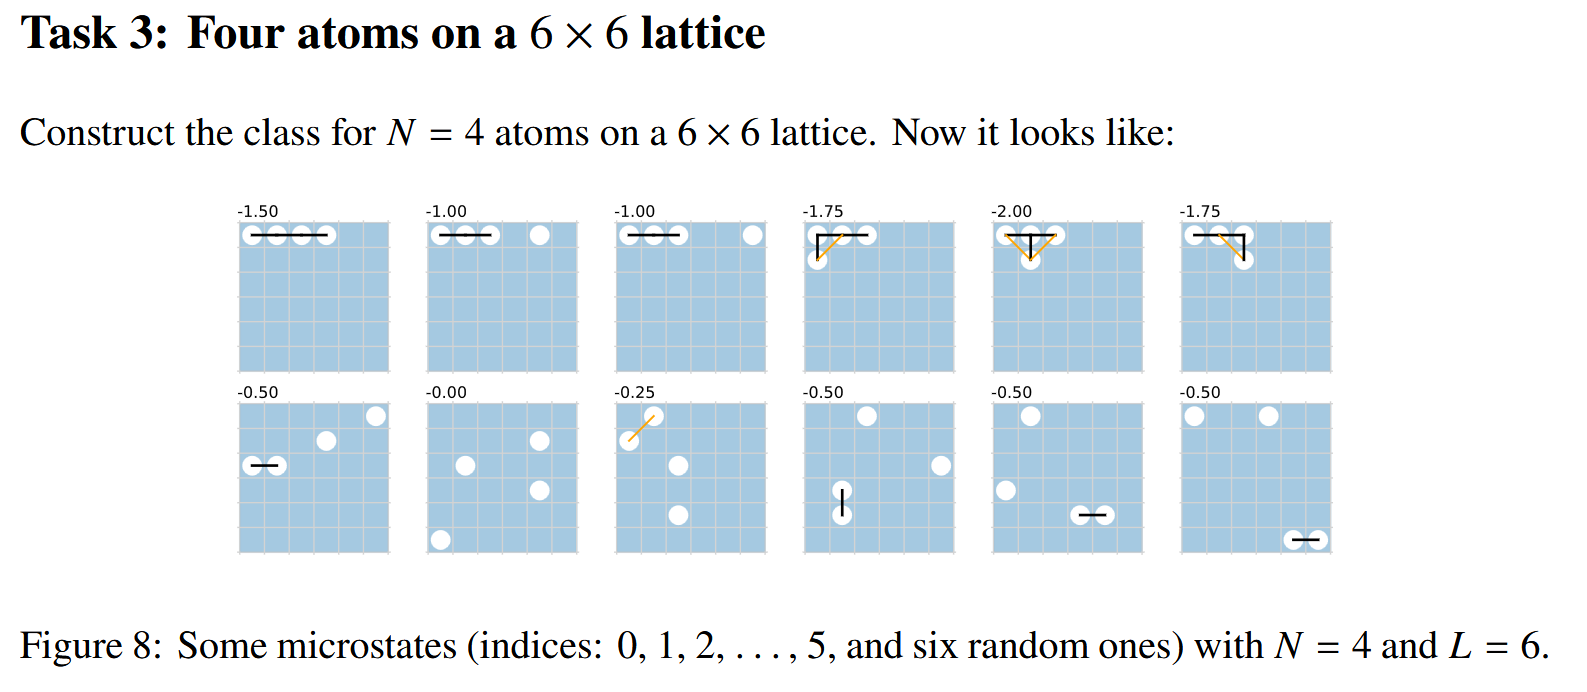
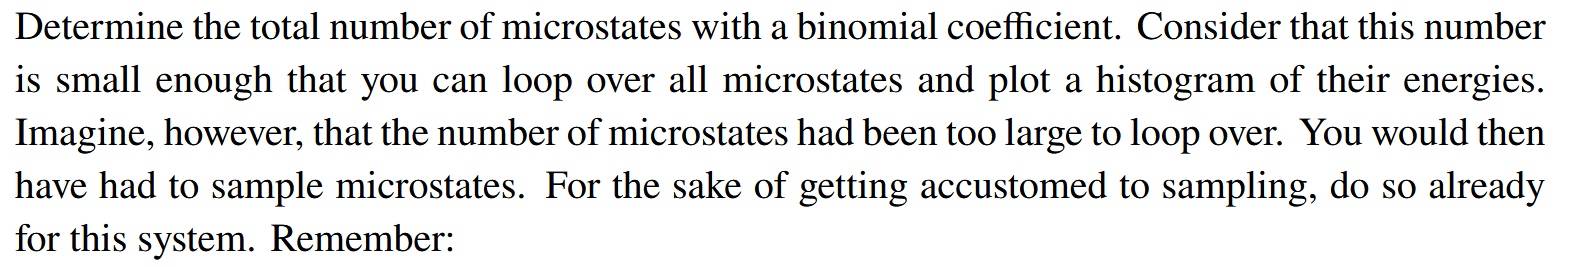


Using binomial: 58905 microstates.


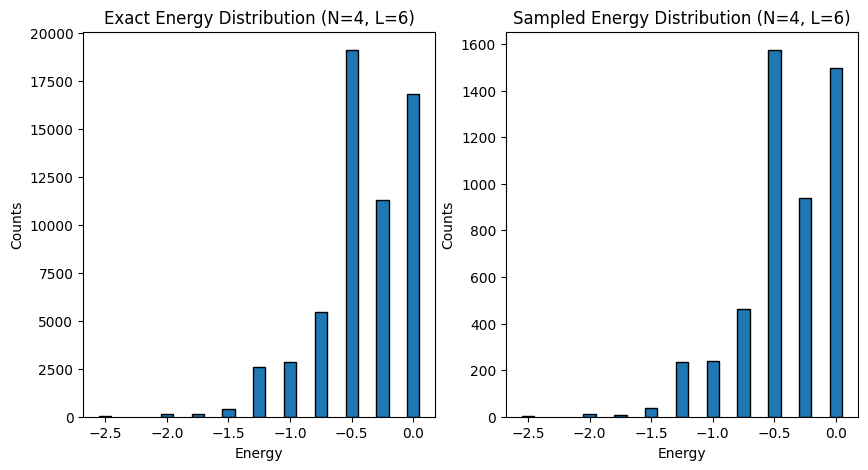

In [4]:
import math
N, L = (4, 6)
total_micro = math.comb(L*L, N)
print(f'Using binomial: {total_micro} microstates.')

MicroState = make_microstate_factory(N, L)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

def hist2(ax, energies, title):
    unique_energies, state_counts = np.unique(energies, return_counts=True)

    ax.bar(unique_energies, state_counts, width=0.1, align='center', edgecolor='black')
    ax.set_xlabel('Energy')
    ax.set_ylabel('Counts')
    ax.set_title(title + ' Energy Distribution (N=4, L=6)')

    return unique_energies, state_counts


exact_energies = []
for i in range(total_micro):
    exact_energies.append(MicroState(i).energy)

ee, ec = hist2(axes[0], exact_energies, 'Exact')

num_samples = 5000
sampled_energies = []
for _ in range(num_samples):
    sampled_energies.append(MicroState().energy)

se, sc = hist2(axes[1], sampled_energies, 'Sampled')


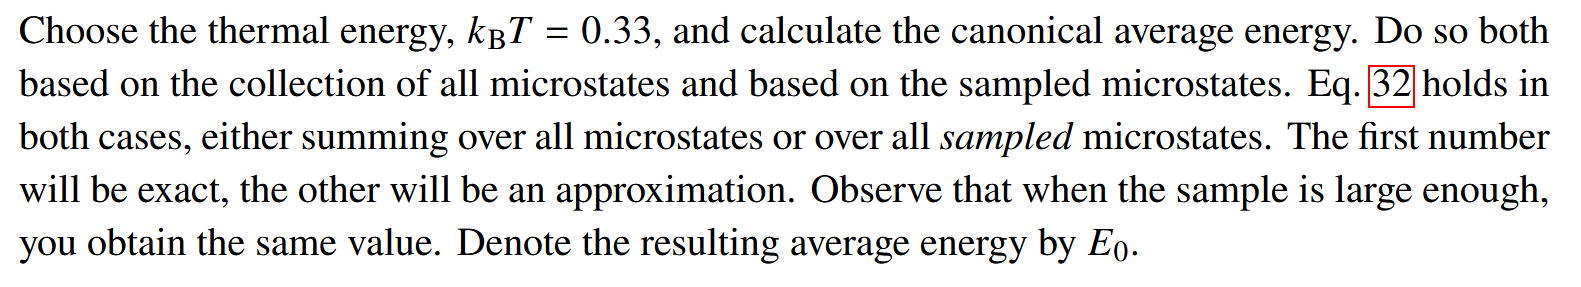

Canonical energy Exact: -1.224
Canonical energy Sampled: -1.289


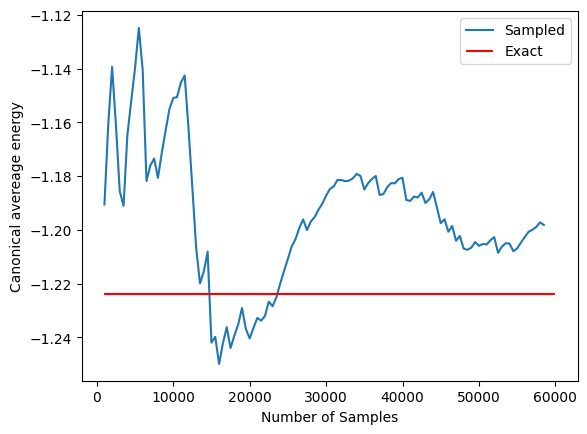

In [5]:
kbT = 0.33

print(f"Canonical energy Exact: {canonical_energy(ee, ec, kbT):.3f}")
print(f"Canonical energy Sampled: {canonical_energy(se, sc, kbT):.3f}")

max_samples = total_micro
all_sampled_energies = np.array([MicroState().energy for _ in range(max_samples)])

num_lin = range(1000, max_samples + 1, 500) 
sampling = []

for n in num_lin:
    subset = all_sampled_energies[:n]
    energy, counts = np.unique(subset, return_counts=True)
    sampling.append(canonical_energy(energy, counts, kbT))

plt.plot(num_lin, sampling, label='Sampled')
plt.hlines(canonical_energy(ee, ec, kbT), 1000, 60000, color='red', label='Exact')
plt.xlabel('Number of Samples')
plt.ylabel('Canonical avereage energy')
plt.legend()


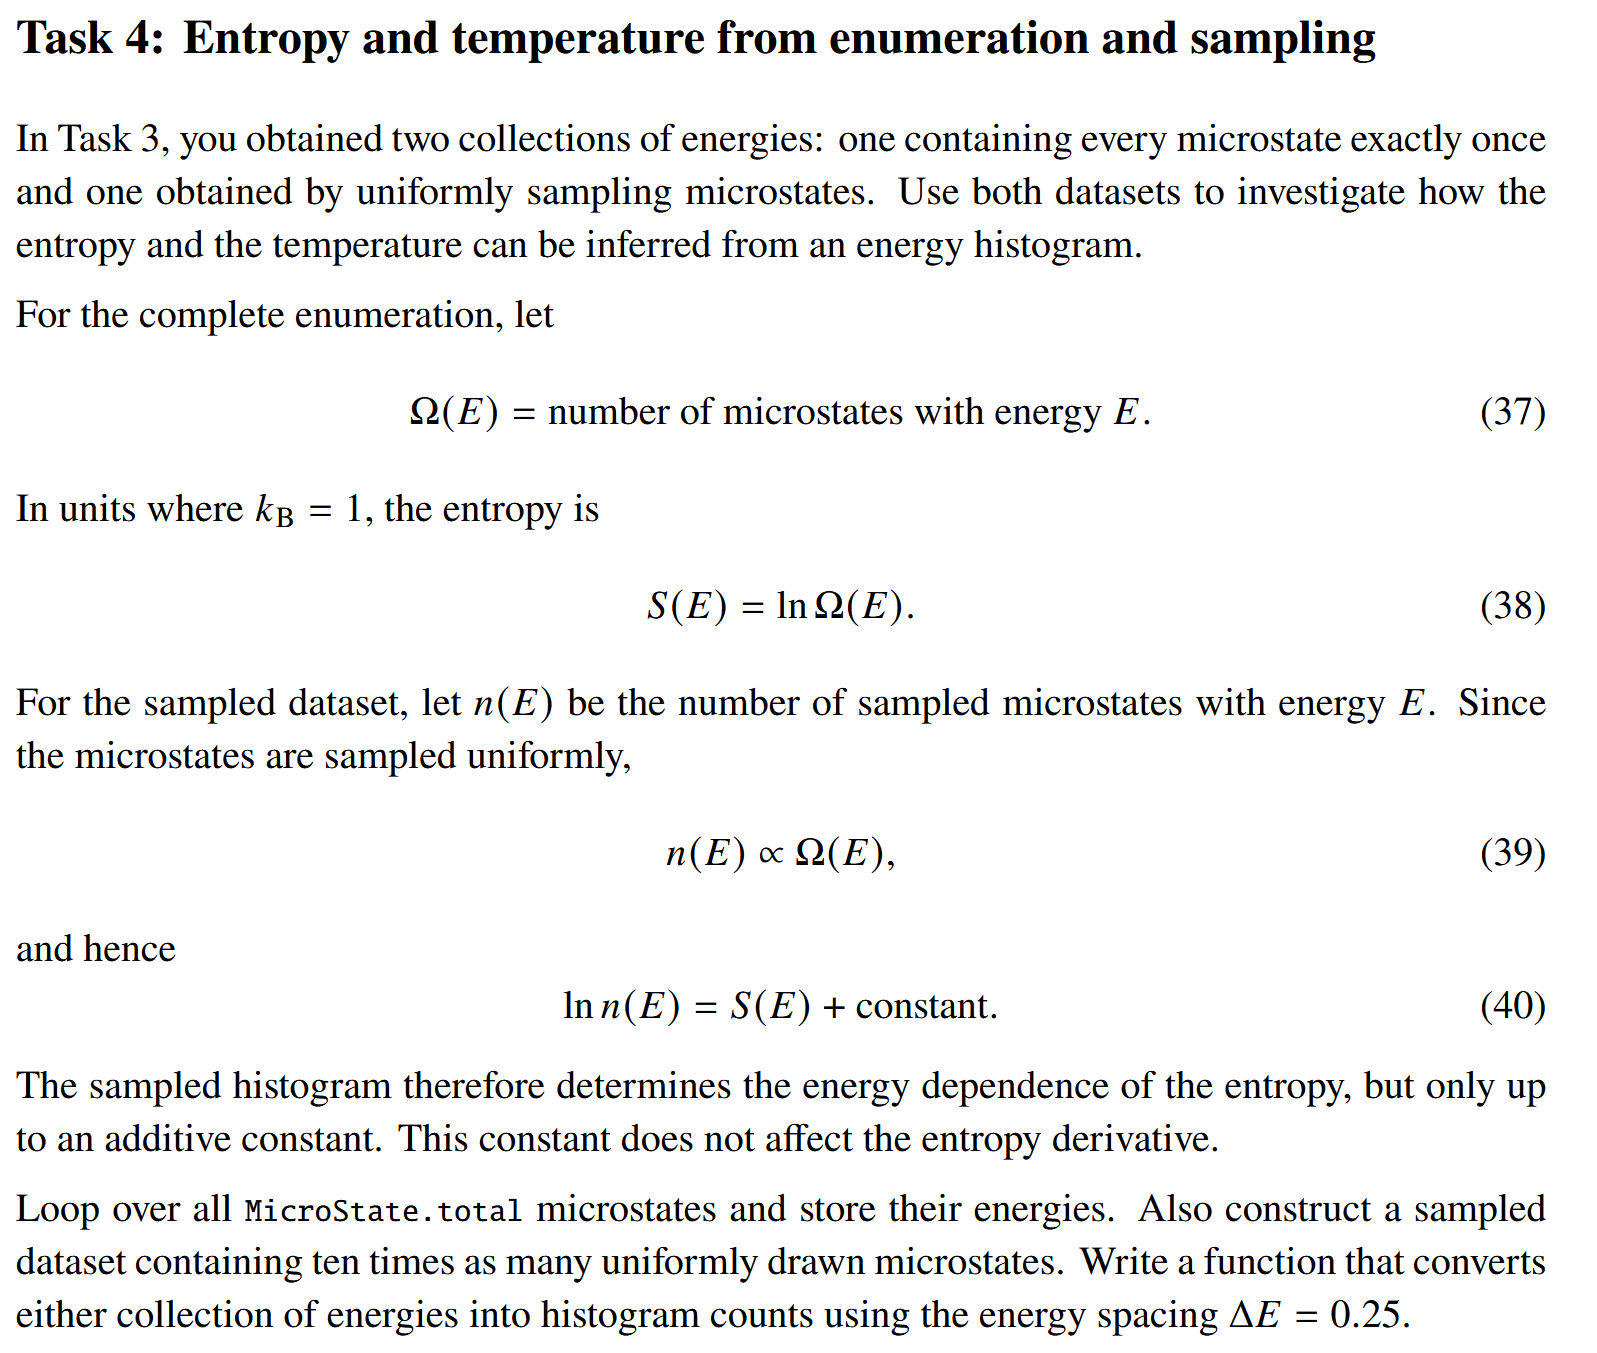
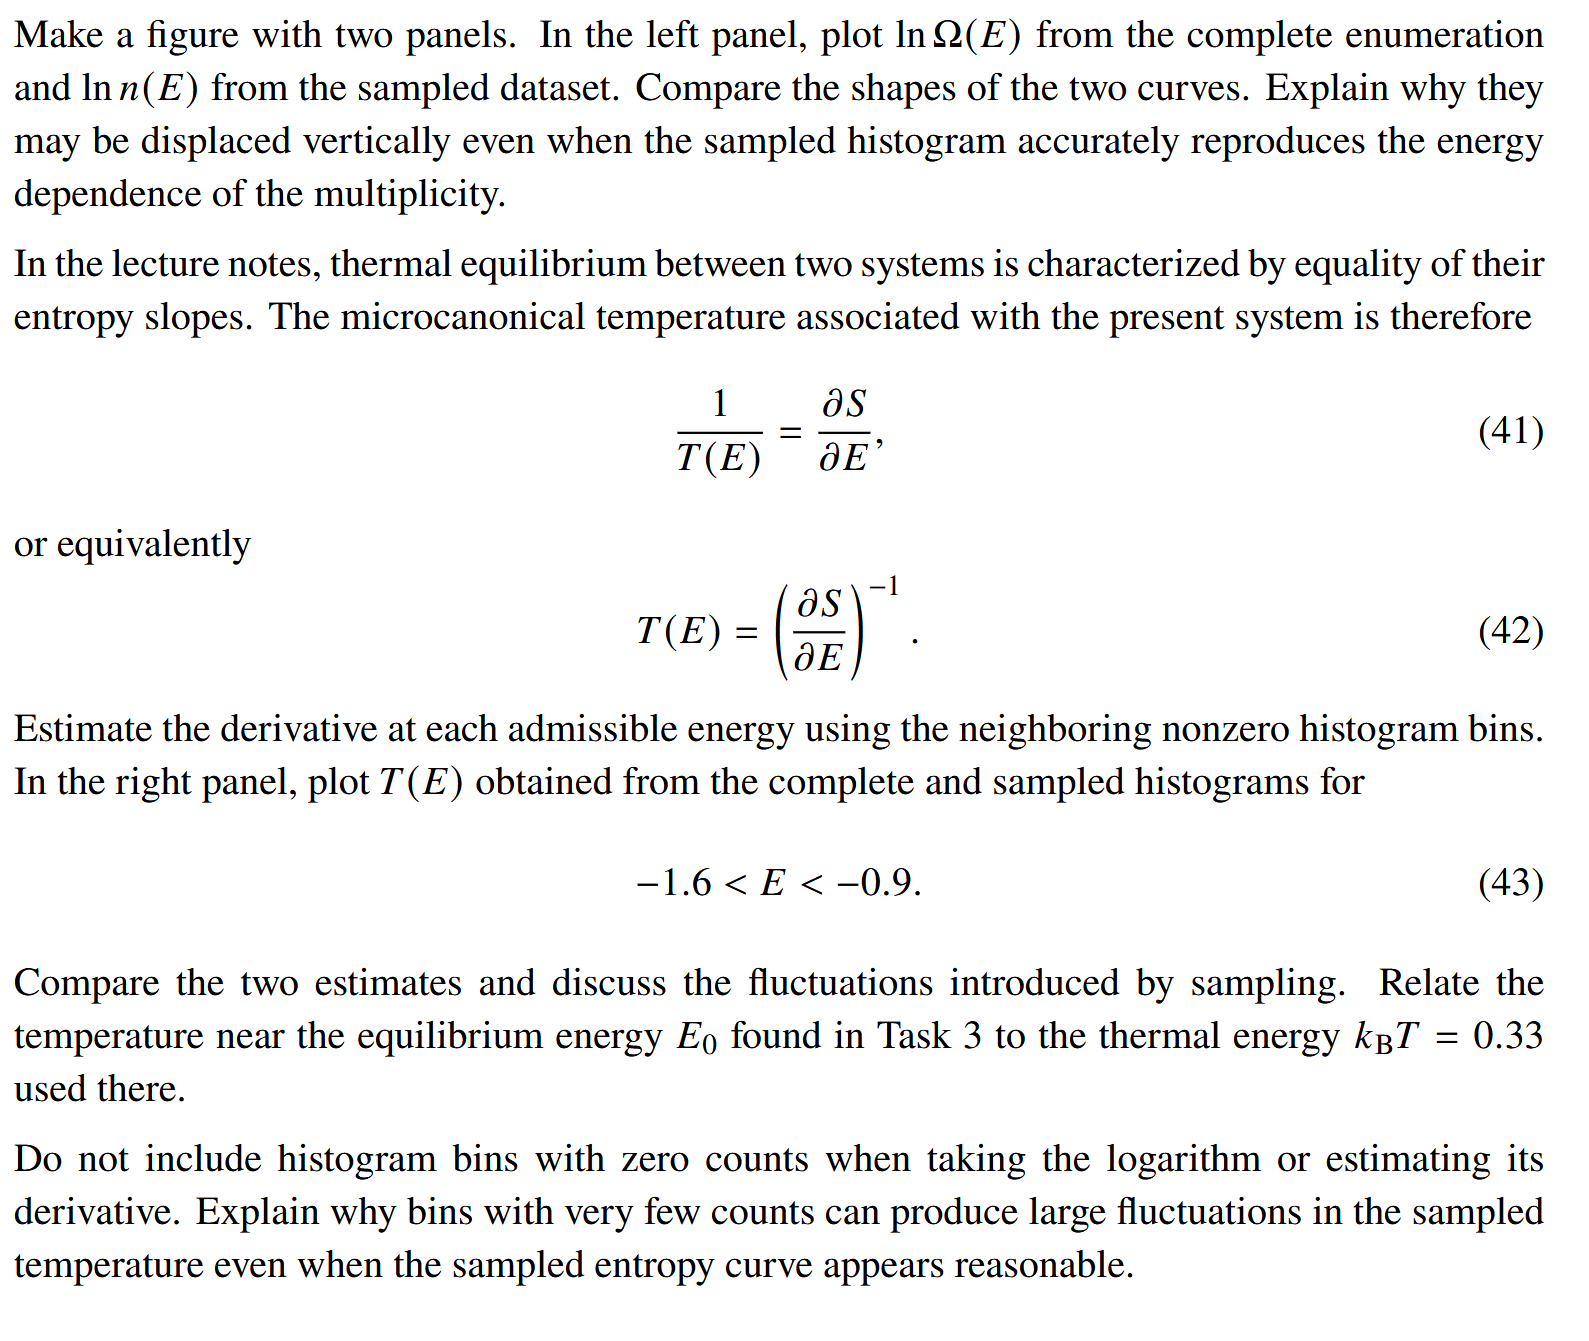

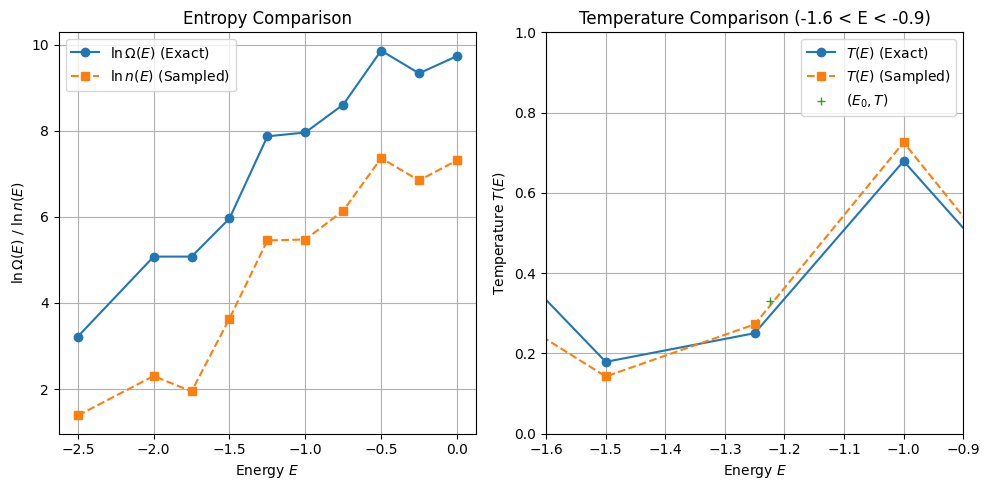

In [ ]:
# Filter out any zero counts to avoid log(0) errors
mask_exact = ec > 0
E_ex = ee[mask_exact]
S_ex = np.log(ec[mask_exact])

mask_sampled = sc > 0
E_samp = se[mask_sampled]
S_samp = np.log(sc[mask_sampled])

dS_ex = np.gradient(S_ex, E_ex)
T_ex = 1.0 / dS_ex

dS_samp = np.gradient(S_samp, E_samp)
T_samp = 1.0 / dS_samp

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Left Panel: Entropy / Log-counts
ax1.plot(E_ex, S_ex, 'o-', label=r'$\ln \Omega(E)$ (Exact)')
ax1.plot(E_samp, S_samp, 's--', label=r'$\ln n(E)$ (Sampled)')
ax1.set_xlabel(r'Energy $E$')
ax1.set_ylabel(r'$\ln \Omega(E)$ / $\ln n(E)$')
ax1.set_title('Entropy Comparison')
ax1.legend()
ax1.grid(True)

# Right Panel: Temperature T(E) restricted to the window -1.6 < E < -0.9
ax2.plot(E_ex, T_ex, 'o-', label=r'$T(E)$ (Exact)')
ax2.plot(E_samp, T_samp, 's--', label=r'$T(E)$ (Sampled)')
ax2.plot(canonical_energy(ee, ec, kbT), kbT, '+', label=r'$(E_0, T)$')
ax2.set_xlim(-1.6, -0.9)
ax2.set_ylim(0, 1) 
ax2.set_xlabel(r'Energy $E$')
ax2.set_ylabel(r'Temperature $T(E)$')
ax2.set_title('Temperature Comparison (-1.6 < E < -0.9)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()


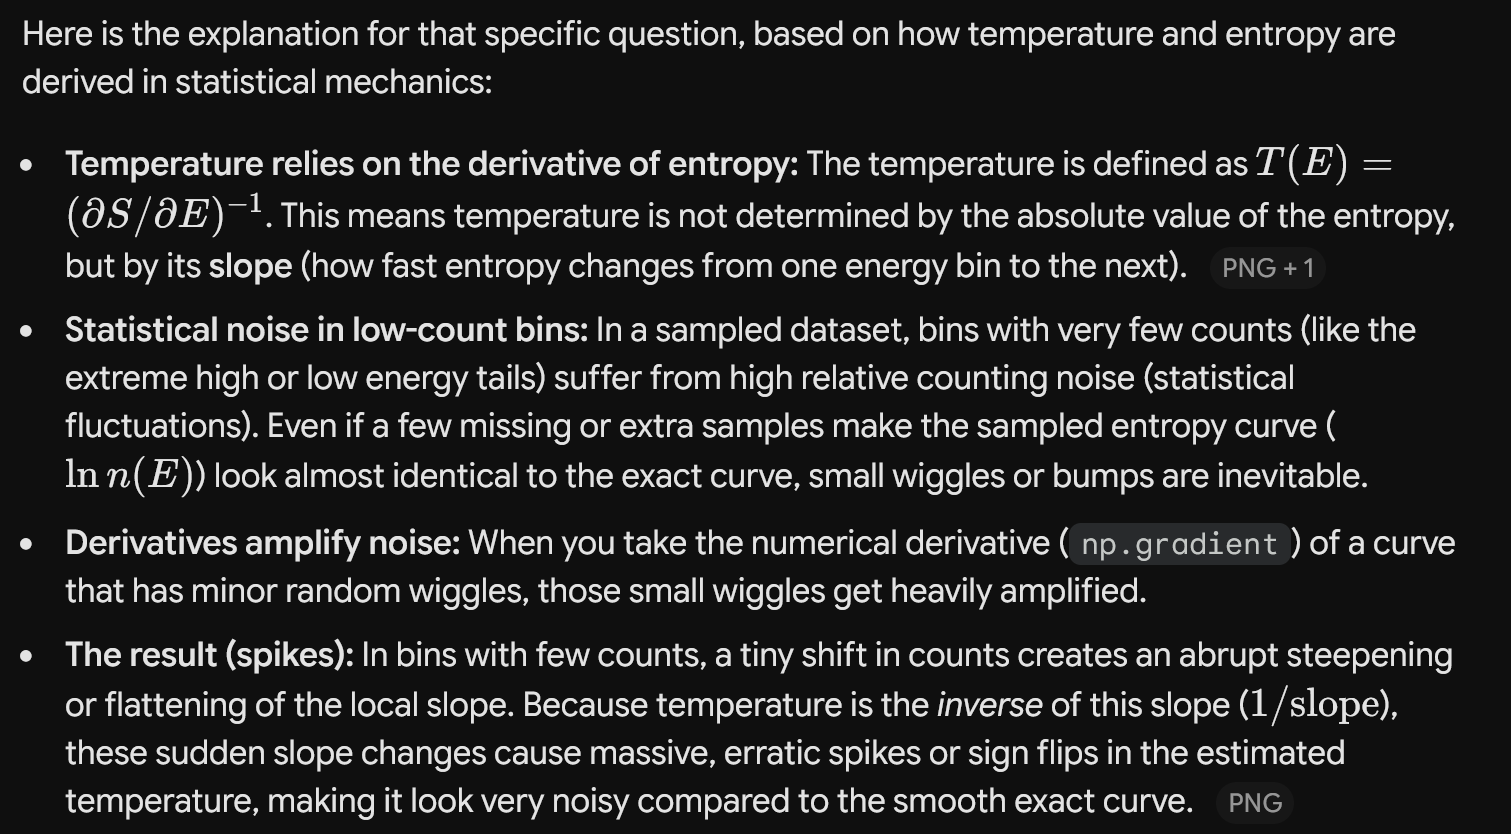

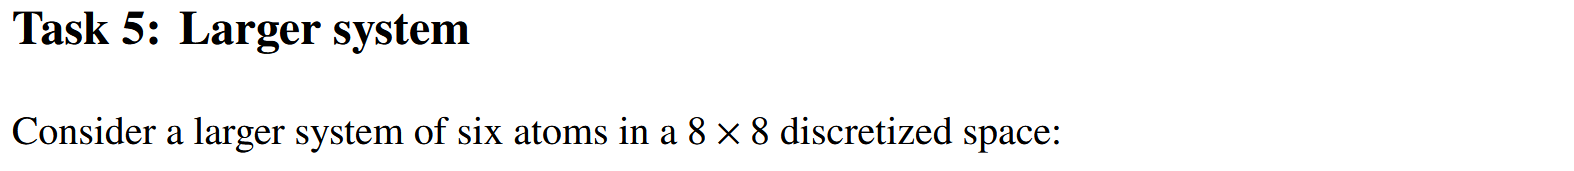
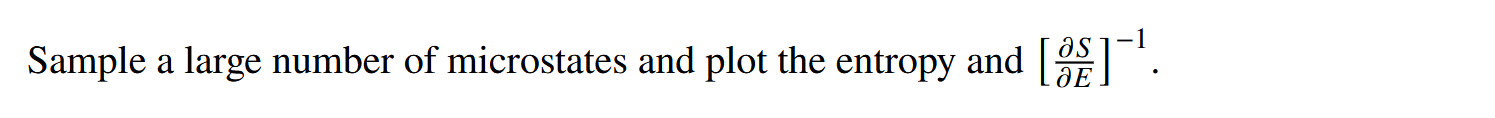
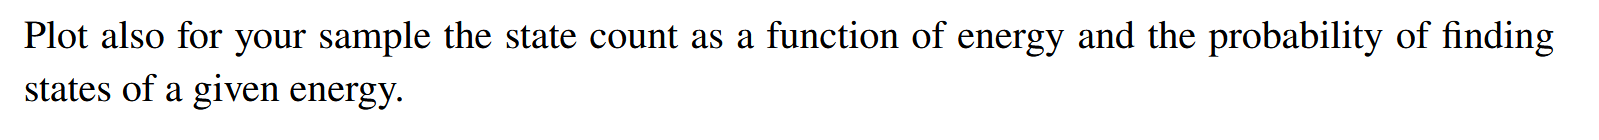
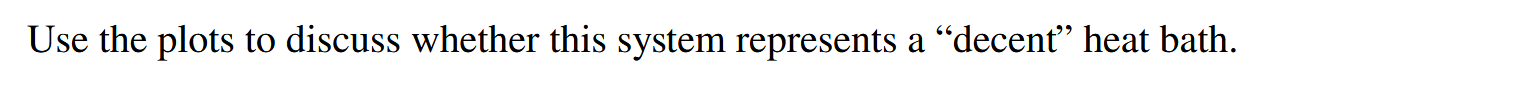

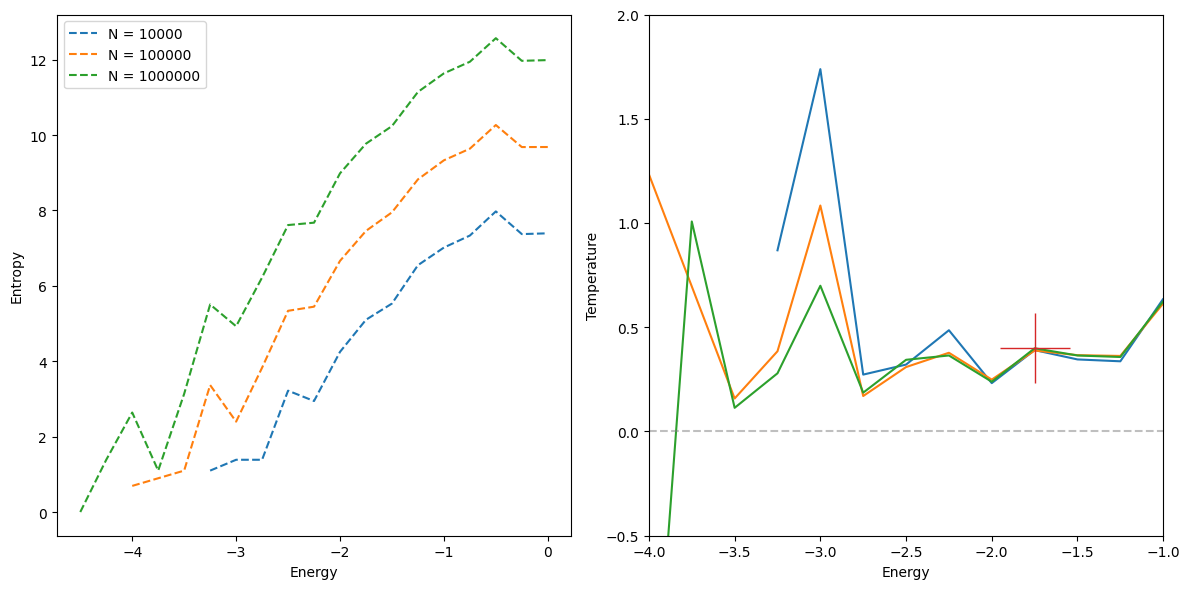

In [47]:
MicroState = make_microstate_factory(6, 8)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

for n in [10_000, 100_000, 1_000_000]:
    energies = [MicroState().energy for _ in range(n)]
    levels, counts = np.unique(energies, return_counts=True)
    mask = counts > 0
    S = np.log(counts[mask])
    T = 1.0 / np.gradient(S, levels[mask])

    ax1.plot(levels[mask], S, '--', label=f'N = {n}')
    ax2.plot(levels[mask], T, label=f'N = {n}')

ax1.set_xlabel('Energy')
ax1.set_ylabel('Entropy')
ax1.legend()

ax2.set_xlabel('Energy')
ax2.set_ylabel('Temperature')
ax2.set_xlim(-4, -1)
ax2.set_ylim(-0.5, 2)

kbT = 0.4
canonical = canonical_energy(levels, counts, kbT)
ax2.plot(canonical, kbT, '+', markersize=50)
ax2.hlines(0.0, -4, -1, linestyle='dashed', color='gray', alpha=0.5)
plt.tight_layout()

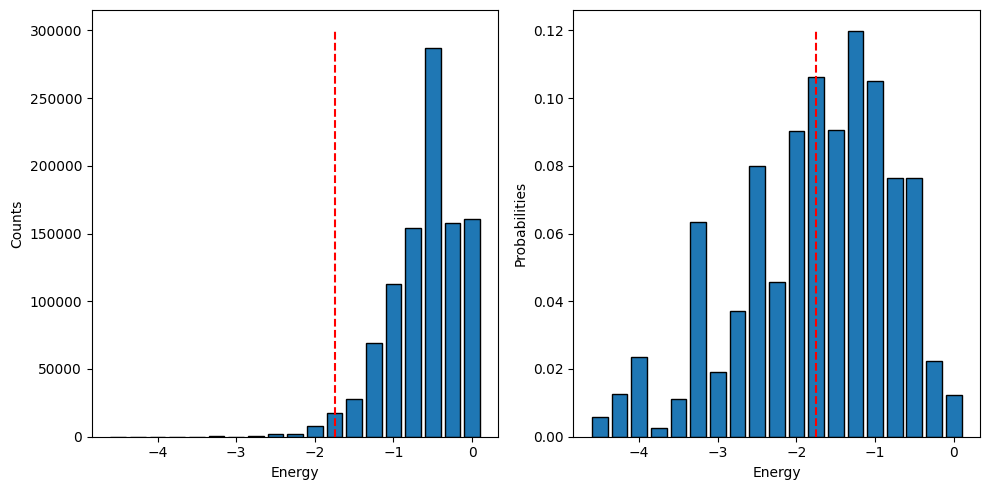

In [51]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

boltzmann_factors = np.exp(-levels / kbT)
unnormalized_prob = counts * boltzmann_factors
probabilities = unnormalized_prob / np.sum(unnormalized_prob)

ax1.bar(levels, counts, width=0.2, align='center', edgecolor='black')
ax2.bar(levels, probabilities, width=0.2, align='center', edgecolor='black')
ax1.vlines(canonical, 0, 300_000, 'r', linestyle='dashed')
ax2.vlines(canonical, 0, 0.12, 'r', linestyle='dashed')

ax1.set_xlabel('Energy')
ax1.set_ylabel('Counts')
ax2.set_xlabel('Energy')
ax2.set_ylabel('Probabilities')
plt.tight_layout()

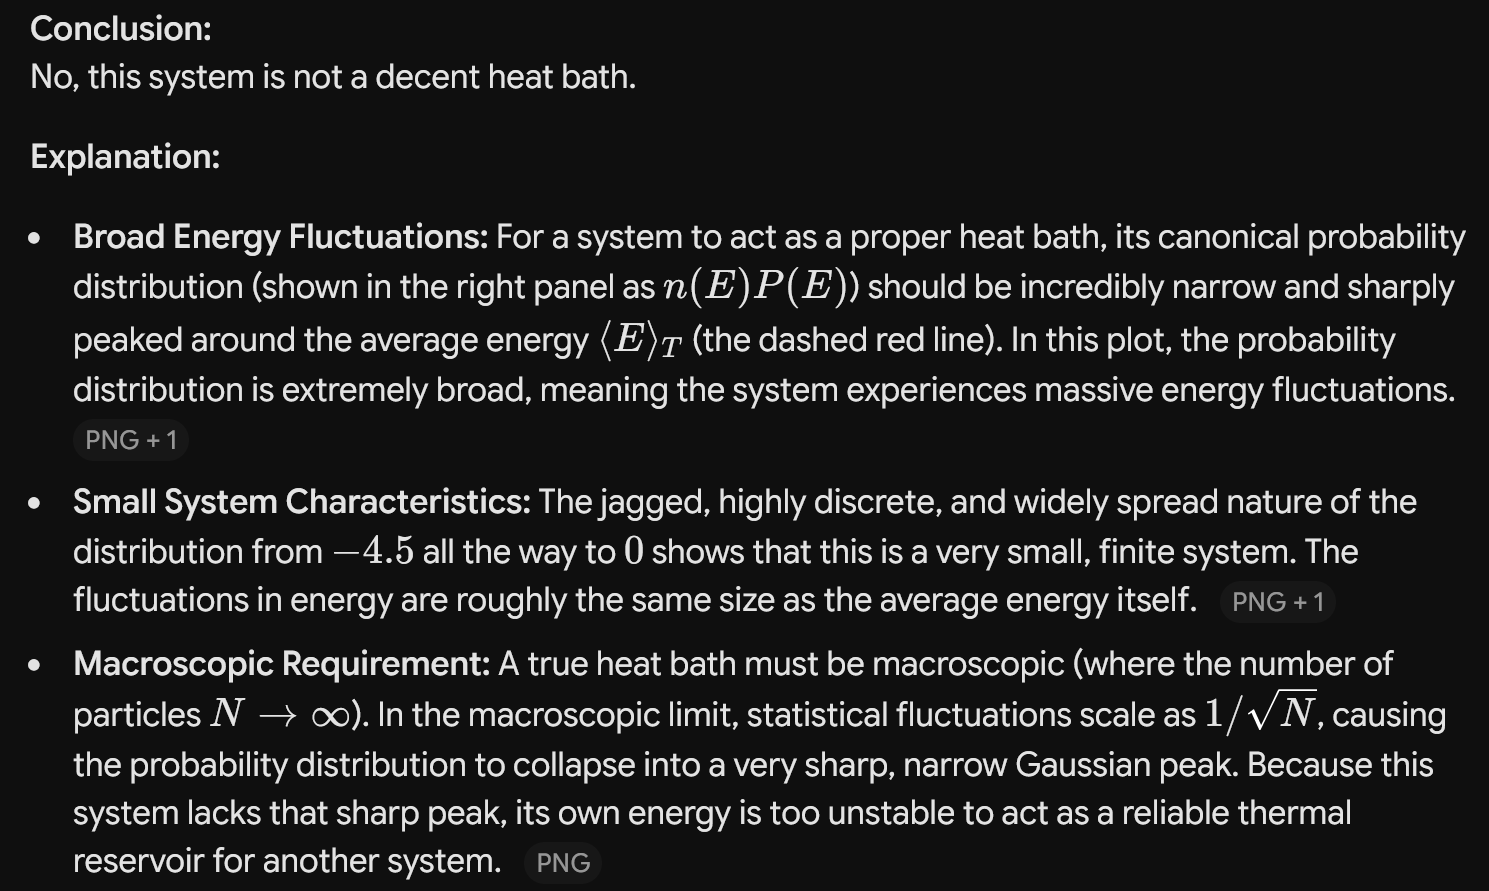